In [2]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from joblib import dump
from h5py import File

import csiborgtools

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [67]:
profile = "gauss"

rvoid, rLG, vrad = csiborgtools.flow.load_void_size_variation("gauss", "vrad", which_run="coarse")

2025-02-17 22:24:20   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_vrad.hdf5`.


In [70]:
!rm /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/void_*

mean_mag = 10.31
std_mag = 0.83
a_TF = -22.8
b_TF = -3
beta = 1

kmax = 1
seed = 4

rvoid_chosen = 1.0  # Fractional void size
rLG_chosen = 20.0   # Mpc
nsamples = 500
sigma_TF = 0.1
sigma_v = 100
Vext_mag = 0
negative_Roffset = True

i = np.abs(rvoid - rvoid_chosen).argmin()
j = np.abs(rLG - rLG_chosen).argmin()
vrad_chosen = vrad[i, j]

# rvoid needs to be converted to percentage
h_void = csiborgtools.flow.select_void_h(100 * rvoid_chosen, "gauss", )
print(f"h_void = {h_void}")

for k in trange(kmax):
    mock, truths = csiborgtools.flow.mock_void(
        vrad_chosen, h_void,
        mean_mag=mean_mag, std_mag=std_mag,
        a_TF=a_TF, b_TF=b_TF, sigma_TF=sigma_TF,
        sigma_v=sigma_v, Vext_mag=Vext_mag, beta=beta,
        negative_Roffset=negative_Roffset,
        seed=seed, nsamples=nsamples, verbose=True,)
    seed += 1

    fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/void_mock_seed{k}.hdf5"  # noqa
    print("Saving to ", fname)
    with File(fname, 'w') as f:
        for key in mock.keys():
            f.create_dataset(key, data=mock[key])

    fname_truths = fname.replace(".hdf5", "_truths.pkl")
    dump(truths, fname_truths)

h_void = 0.7732155199999999


  0%|          | 0/1 [00:00<?, ?it/s]

Assuming grid of 181 points in phi and 401 points in r.


100%|██████████| 1/1 [00:00<00:00,  5.63it/s]

Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/void_mock_seed0.hdf5


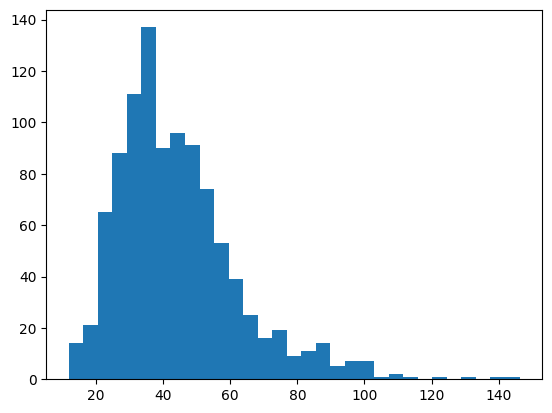

In [31]:
plt.figure()
plt.hist(mock["r"], bins="auto")

plt.show()